
Loading MRI volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Loaded Successfully!

MRI Shape = (181, 217, 181)

Datatype = uint8

Minimum = 0
Maximum = 255

After Normalization:
Minimum = 0.0
Maximum = 1.0


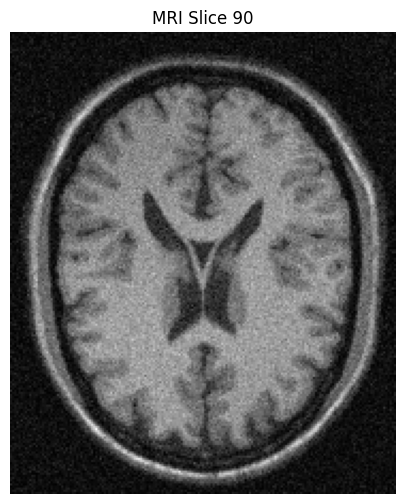


MRI Ready For 3D U-Net!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILE PATH
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn9_rf40.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI volume...")

mri_volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mri_volume.size)

if mri_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mri_volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

mri_volume = mri_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Loaded Successfully!")

print("\nMRI Shape =", mri_volume.shape)

print("\nDatatype =", mri_volume.dtype)

# ============================================================
# CHECK RANGE
# ============================================================

print("\nMinimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# NORMALIZE
# ============================================================

mri_volume = mri_volume.astype(np.float32)

mri_volume = mri_volume / 255.0

print("\nAfter Normalization:")

print("Minimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# DISPLAY SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title(f"MRI Slice {slice_index}")

plt.axis("off")

plt.show()

print("\nMRI Ready For 3D U-Net!")


Loading Ground Truth Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

Ground Truth Loaded Successfully!

Ground Truth Shape = (181, 217, 181)

Datatype = uint8

Unique Labels Found:
[0 1 2 3 4 5 6 7 8 9]


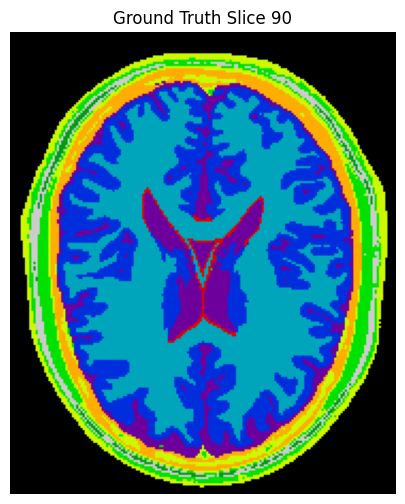


Ground Truth Ready For Training!


In [2]:
#Load Segmentation Label
# ============================================================
# LOAD SEGMENTATION LABEL VOLUME
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GROUND TRUTH FILE
# ============================================================

GT_PATH = "phantom_1.0mm_normal_crisp.rawb"

# ============================================================
# GROUND TRUTH DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD GROUND TRUTH
# ============================================================

print("\nLoading Ground Truth Volume...")

gt_volume = np.fromfile(
    GT_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", gt_volume.size)

if gt_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {gt_volume.size}"
    )

# ============================================================
# RESHAPE INTO 3D
# ============================================================

gt_volume = gt_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nGround Truth Loaded Successfully!")

print("\nGround Truth Shape =", gt_volume.shape)

print("\nDatatype =", gt_volume.dtype)

# ============================================================
# CHECK LABEL VALUES
# ============================================================

unique_labels = np.unique(gt_volume)

print("\nUnique Labels Found:")

print(unique_labels)

# ============================================================
# DISPLAY MIDDLE SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    gt_volume[slice_index],
    cmap='nipy_spectral'
)

plt.title(f"Ground Truth Slice {slice_index}")

plt.axis("off")

plt.show()

# ============================================================
# READY
# ============================================================

print("\nGround Truth Ready For Training!")


Loading MRI Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Shape = (181, 217, 181)

Converting To Float32...

Scaling Intensities To [0,1]...

Applying Z-Score Normalization...

Mean = 0.18926457
Std = 0.16645736

Z-Score Normalization Completed!

Final Intensity Statistics
Minimum = -1.1134562
Maximum = 4.870529
Mean = -3.4903886e-07
Std = 0.9999998


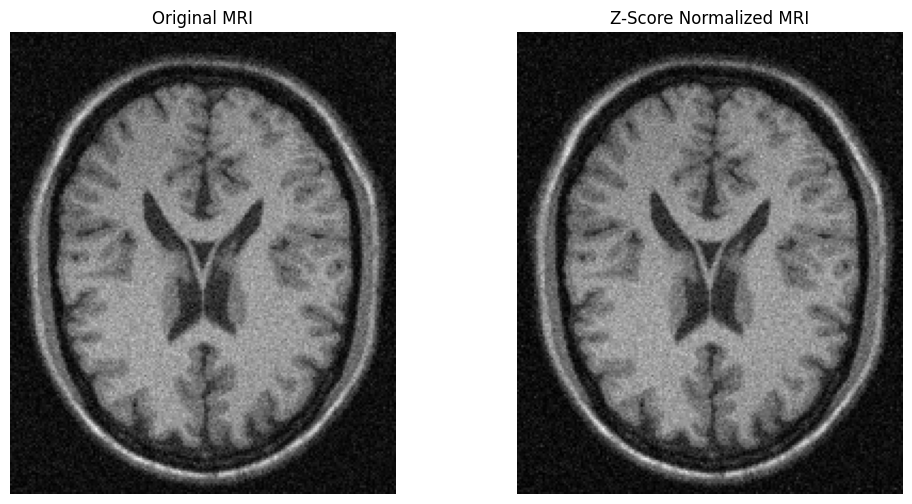


Preprocessing Completed!

Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization


MRI Ready For 3D U-Net!


In [3]:
# ============================================================
# PREPROCESSING + Z-SCORE NORMALIZATION ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MRI FILE
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn9_rf40.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI Volume...")

volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = (
    DEPTH *
    HEIGHT *
    WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", volume.size)

if volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

volume = volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Shape =", volume.shape)

# ============================================================
# CONVERT TO FLOAT32
# ============================================================

print("\nConverting To Float32...")

volume = volume.astype(np.float32)

# ============================================================
# SCALE TO [0,1]
# ============================================================

print("\nScaling Intensities To [0,1]...")

volume = volume / 255.0

# ============================================================
# Z-SCORE NORMALIZATION ONLY
# ============================================================

print("\nApplying Z-Score Normalization...")

# ------------------------------------------------------------
# USE NON-ZERO VOXELS ONLY
# ------------------------------------------------------------

brain_voxels = volume[
    volume > 0
]

mean = np.mean(
    brain_voxels
)

std = np.std(
    brain_voxels
)

print("\nMean =", mean)

print("Std =", std)

# ------------------------------------------------------------
# Z-SCORE FORMULA
# ------------------------------------------------------------

normalized_volume = (
    volume - mean
) / (
    std + 1e-8
)

# ------------------------------------------------------------
# KEEP BACKGROUND BLACK
# ------------------------------------------------------------

normalized_volume[
    volume == 0
] = 0

print("\nZ-Score Normalization Completed!")

# ============================================================
# CHECK FINAL RANGE
# ============================================================

print("\nFinal Intensity Statistics")

print("Minimum =",
      np.min(normalized_volume))

print("Maximum =",
      np.max(normalized_volume))

print("Mean =",
      np.mean(
          normalized_volume[
              volume > 0
          ]
      ))

print("Std =",
      np.std(
          normalized_volume[
              volume > 0
          ]
      ))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(12,6))

# ------------------------------------------------------------
# ORIGINAL MRI
# ------------------------------------------------------------

plt.subplot(1,2,1)

plt.imshow(
    volume[slice_index],
    cmap='gray'
)

plt.title("Original MRI")

plt.axis("off")

# ------------------------------------------------------------
# NORMALIZED MRI
# ------------------------------------------------------------

plt.subplot(1,2,2)

plt.imshow(
    normalized_volume[slice_index],
    cmap='gray'
)

plt.title("Z-Score Normalized MRI")

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("\nPreprocessing Completed!")

print("""
Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization
""")

print("\nMRI Ready For 3D U-Net!")

In [4]:
# skull s


MRI Shape = (181, 217, 181)
Ground Truth Shape = (181, 217, 181)

Unique Labels After Cleanup
[0 1 2 3]

Extracting 3D Patches...

Total Valid Patches = 150

Image Patch Shape = (150, 32, 32, 32, 1)
Mask Patch Shape = (150, 32, 32, 32)

One Patch Shape = (32, 32, 32, 1)

Patch Intensity Range
Minimum = 0.0
Maximum = 1.0

Unique Labels In Mask Patches
[0 1 2 3]

Selecting Best Brain Patch...
Best Patch Index = 108


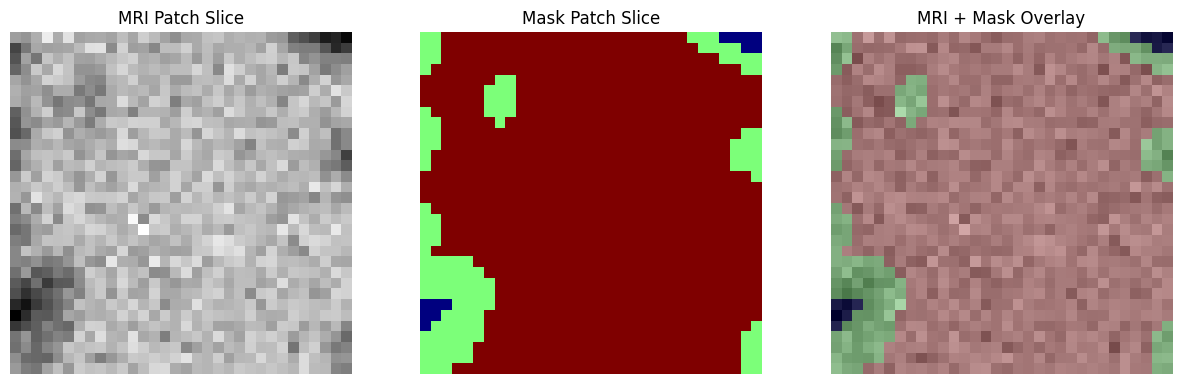


Patch Extraction Completed Successfully!

Ready For 3D U-Net Dataset Creation!

Final Dataset Information
Total Image Patches = 150
Total Mask Patches = 150
Patch Size = 32
Stride = 32


In [5]:
#Patch Extraction
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATCH PARAMETERS
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nMRI Shape =", volume.shape)

print("Ground Truth Shape =", gt_volume.shape)

# ============================================================
# KEEP ONLY 3 CLASSES
# ============================================================

gt_volume[gt_volume > 3] = 0

print("\nUnique Labels After Cleanup")

print(np.unique(gt_volume))

# ============================================================
# PATCH STORAGE
# ============================================================

image_patches = []

mask_patches = []

DEPTH, HEIGHT, WIDTH = volume.shape

print("\nExtracting 3D Patches...")

patch_count = 0

# ============================================================
# PATCH EXTRACTION
# ============================================================

for z in range(
    0,
    DEPTH - PATCH_SIZE + 1,
    STRIDE
):

    for y in range(
        0,
        HEIGHT - PATCH_SIZE + 1,
        STRIDE
    ):

        for x in range(
            0,
            WIDTH - PATCH_SIZE + 1,
            STRIDE
        ):

            image_patch = volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            mask_patch = gt_volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            # ------------------------------------------------
            # REMOVE EMPTY PATCHES
            # ------------------------------------------------

            if np.sum(image_patch) > 5:

                image_patches.append(
                    image_patch
                )

                mask_patches.append(
                    mask_patch
                )

                patch_count += 1

# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

print("\nTotal Valid Patches =",
      patch_count)

image_patches = np.array(
    image_patches,
    dtype=np.float32
)

mask_patches = np.array(
    mask_patches,
    dtype=np.uint8
)

# ============================================================
# ADD CHANNEL DIMENSION
# ============================================================

image_patches = np.expand_dims(
    image_patches,
    axis=-1
)

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nImage Patch Shape =",
      image_patches.shape)

print("Mask Patch Shape =",
      mask_patches.shape)

print("\nOne Patch Shape =",
      image_patches[0].shape)

print("\nPatch Intensity Range")

print("Minimum =",
      np.min(image_patches))

print("Maximum =",
      np.max(image_patches))

print("\nUnique Labels In Mask Patches")

print(np.unique(mask_patches))

# ============================================================
# FIND BEST PATCH
# ============================================================

print("\nSelecting Best Brain Patch...")

best_patch_index = 0

max_intensity = 0

for i in range(len(image_patches)):

    patch_sum = np.sum(
        image_patches[i]
    )

    if patch_sum > max_intensity:

        max_intensity = patch_sum

        best_patch_index = i

print("Best Patch Index =",
      best_patch_index)

# ============================================================
# VISUALIZATION
# ============================================================

sample_patch = image_patches[
    best_patch_index
]

sample_mask = mask_patches[
    best_patch_index
]

middle_slice = PATCH_SIZE // 2

plt.figure(figsize=(15,5))

# ---------------- MRI PATCH ----------------

plt.subplot(1,3,1)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.title("MRI Patch Slice")

plt.axis("off")

# ---------------- MASK PATCH ----------------

plt.subplot(1,3,2)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet'
)

plt.title("Mask Patch Slice")

plt.axis("off")

# ---------------- OVERLAY ----------------

plt.subplot(1,3,3)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Mask Overlay")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nPatch Extraction Completed Successfully!")

print("\nReady For 3D U-Net Dataset Creation!")

print("\nFinal Dataset Information")

print("Total Image Patches =",
      len(image_patches))

print("Total Mask Patches =",
      len(mask_patches))

print("Patch Size =",
      PATCH_SIZE)

print("Stride =",
      STRIDE)

In [6]:
# ============================================================
# CONVERT PATCHES TO PYTORCH FORMAT
# ATTENTION 3D U-NET
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import numpy as np

print("\nConverting Patches To PyTorch Tensors...")

# ============================================================
# PATCH + STRIDE CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# NUMPY -> TORCH
# ============================================================

print("\nChecking Input Types...")

if isinstance(image_patches, np.ndarray):

    print("Converting Image Patches To Tensor...")

    image_patches = torch.from_numpy(
        image_patches
    ).float()

if isinstance(mask_patches, np.ndarray):

    print("Converting Mask Patches To Tensor...")

    mask_patches = torch.from_numpy(
        mask_patches
    ).long()

# ============================================================
# CURRENT SHAPES
# ============================================================

print("\nCurrent Image Tensor Shape =",
      image_patches.shape)

print("Current Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# CURRENT FORMAT
# ============================================================

print("\nCurrent Tensor Format")

print("""
Images:
[B, D, H, W, C]

Masks:
[B, D, H, W]
""")

# ============================================================
# REQUIRED FORMAT FOR ATTENTION 3D U-NET
# ============================================================

print("\nRequired Format")

print("""
Images:
[B, C, D, H, W]

Masks:
[B, D, H, W]
""")

# ============================================================
# REORDER DIMENSIONS
# ============================================================

if len(image_patches.shape) == 5:

    print("\nReordering Tensor Dimensions...")

    image_patches = image_patches.permute(
        0, 4, 1, 2, 3
    )

# ============================================================
# ENSURE CONTIGUOUS MEMORY
# ============================================================

print("\nMaking Tensors Contiguous...")

image_patches = image_patches.contiguous()

mask_patches = mask_patches.contiguous()

# ============================================================
# FINAL SHAPES
# ============================================================

print("\nFinal Image Tensor Shape =",
      image_patches.shape)

print("Final Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# DIMENSION MEANING
# ============================================================

print("\nTensor Dimension Meaning")

print("""
Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]
""")

# ============================================================
# DIMENSION INTERPRETATION
# ============================================================

print("\nDimension Interpretation")

print("Batch Size =",
      image_patches.shape[0])

print("Channels =",
      image_patches.shape[1])

print("Depth =",
      image_patches.shape[2])

print("Height =",
      image_patches.shape[3])

print("Width =",
      image_patches.shape[4])

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nPatch Information")

print(f"""
Patch Shape:

{PATCH_SIZE} × {PATCH_SIZE} × {PATCH_SIZE}

Stride = {STRIDE}
""")

# ============================================================
# OVERLAP INFORMATION
# ============================================================

overlap = PATCH_SIZE - STRIDE

print("\nPatch Overlap")

print("Overlap =", overlap)

if overlap == 0:

    print("""
No overlap exists.

Each patch is processed independently.
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# ATTENTION U-NET INFORMATION
# ============================================================

print("\nAttention 3D U-Net Input Requirements")

print("""
Attention U-Net expects:

Input:
[B, C, D, H, W]

Example:
[2, 1, 32, 32, 32]
""")

print("""
The attention gates operate on:

- encoder feature maps
- decoder feature maps

Correct tensor ordering is essential.
""")

# ============================================================
# VERIFY LABELS
# ============================================================

print("\nUnique Labels In Mask Tensor")

print(torch.unique(mask_patches))

# ============================================================
# LABEL INTERPRETATION
# ============================================================

print("\nLabel Meaning")

print("""
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# VERIFY DTYPE
# ============================================================

print("\nImage Tensor Dtype =",
      image_patches.dtype)

print("Mask Tensor Dtype =",
      mask_patches.dtype)

# ============================================================
# VERIFY SHAPE COMPATIBILITY
# ============================================================

print("\nVerifying Shape Compatibility...")

if image_patches.shape[2] == PATCH_SIZE:

    print("Depth Compatible")

if image_patches.shape[3] == PATCH_SIZE:

    print("Height Compatible")

if image_patches.shape[4] == PATCH_SIZE:

    print("Width Compatible")

# ============================================================
# ATTENTION MODEL PIPELINE
# ============================================================

print("\nAttention 3D U-Net Pipeline")

print("""
MRI Volume
     ↓
Patch Extraction
(32×32×32)
     ↓
Tensor Conversion
[B,C,D,H,W]
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Softmax Probabilities
     ↓
Segmentation Prediction
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("\nModel Type = Attention 3D U-Net")

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("\nFinal Image Tensor Shape =")

print(image_patches.shape)

print("\nFinal Mask Tensor Shape =")

print(mask_patches.shape)

print("\nPyTorch Tensor Preparation Completed Successfully!")



Converting Patches To PyTorch Tensors...

Patch Size = 32
Stride = 32

Checking Input Types...
Converting Image Patches To Tensor...
Converting Mask Patches To Tensor...

Current Image Tensor Shape = torch.Size([150, 32, 32, 32, 1])
Current Mask Tensor Shape = torch.Size([150, 32, 32, 32])

Current Tensor Format

Images:
[B, D, H, W, C]

Masks:
[B, D, H, W]


Required Format

Images:
[B, C, D, H, W]

Masks:
[B, D, H, W]


Reordering Tensor Dimensions...

Making Tensors Contiguous...

Final Image Tensor Shape = torch.Size([150, 1, 32, 32, 32])
Final Mask Tensor Shape = torch.Size([150, 32, 32, 32])

Tensor Dimension Meaning

Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]


Dimension Interpretation
Batch Size = 150
Channels = 1
Depth = 32
Height = 32
Width = 32

Patch Information

Patch Shape:

32 × 32 × 32

Stride = 32


Patch Overlap
Overlap = 0

No overlap exists.

Each patch is processed independently.


Attention 3D U-Net Input Requirements

At

In [7]:
# ============================================================
# ATTENTION 3D U-NET ARCHITECTURE
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import torch.nn as nn

print("\nCreating Attention 3D U-Net Architecture...")

# ============================================================
# PATCH CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# ATTENTION BLOCK
# ============================================================

class AttentionBlock(nn.Module):

    def __init__(
        self,
        F_g,
        F_l,
        F_int
    ):

        super(AttentionBlock, self).__init__()

        # ----------------------------------------------------
        # GATING SIGNAL
        # ----------------------------------------------------

        self.W_g = nn.Sequential(

            nn.Conv3d(
                F_g,
                F_int,
                kernel_size=1,
                stride=1,
                padding=0
            ),

            nn.BatchNorm3d(F_int)
        )

        # ----------------------------------------------------
        # ENCODER FEATURE
        # ----------------------------------------------------

        self.W_x = nn.Sequential(

            nn.Conv3d(
                F_l,
                F_int,
                kernel_size=1,
                stride=1,
                padding=0
            ),

            nn.BatchNorm3d(F_int)
        )

        # ----------------------------------------------------
        # ATTENTION MAP
        # ----------------------------------------------------

        self.psi = nn.Sequential(

            nn.Conv3d(
                F_int,
                1,
                kernel_size=1,
                stride=1,
                padding=0
            ),

            nn.BatchNorm3d(1),

            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, g, x):

        # ----------------------------------------------------
        # GATING FEATURE
        # ----------------------------------------------------

        g1 = self.W_g(g)

        # ----------------------------------------------------
        # ENCODER FEATURE
        # ----------------------------------------------------

        x1 = self.W_x(x)

        # ----------------------------------------------------
        # ATTENTION COMPUTATION
        # ----------------------------------------------------

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        # ----------------------------------------------------
        # APPLY ATTENTION
        # ----------------------------------------------------

        out = x * psi

        return out

# ============================================================
# ATTENTION 3D U-NET
# ============================================================

class AttentionUNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super(AttentionUNet3D, self).__init__()

        print("\nBuilding Encoder Path...")

        # ====================================================
        # ENCODER
        # ====================================================

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(
            kernel_size=2
        )

        # ====================================================
        # BOTTLENECK
        # ====================================================

        print("\nBuilding Bottleneck...")

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ====================================================
        # DECODER
        # ====================================================

        print("\nBuilding Decoder Path...")

        # ----------------------------------------------------
        # DECODER LEVEL 3
        # ----------------------------------------------------

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.att3 = AttentionBlock(
            F_g=128,
            F_l=128,
            F_int=64
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        # ----------------------------------------------------
        # DECODER LEVEL 2
        # ----------------------------------------------------

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.att2 = AttentionBlock(
            F_g=64,
            F_l=64,
            F_int=32
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        # ----------------------------------------------------
        # DECODER LEVEL 1
        # ----------------------------------------------------

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.att1 = AttentionBlock(
            F_g=32,
            F_l=32,
            F_int=16
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ====================================================
        # FINAL OUTPUT
        # ====================================================

        print("\nCreating Final Output Layer...")

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        # ====================================================
        # ENCODER LEVEL 1
        # ====================================================

        e1 = self.enc1(x)

        print("\nEncoder Level 1 =", e1.shape)

        p1 = self.pool1(e1)

        # ====================================================
        # ENCODER LEVEL 2
        # ====================================================

        e2 = self.enc2(p1)

        print("Encoder Level 2 =", e2.shape)

        p2 = self.pool2(e2)

        # ====================================================
        # ENCODER LEVEL 3
        # ====================================================

        e3 = self.enc3(p2)

        print("Encoder Level 3 =", e3.shape)

        p3 = self.pool3(e3)

        # ====================================================
        # BOTTLENECK
        # ====================================================

        b = self.bottleneck(p3)

        print("Bottleneck =", b.shape)

        # ====================================================
        # DECODER LEVEL 3
        # ====================================================

        u3 = self.up3(b)

        print("\nUpsample 3 =", u3.shape)

        # ----------------------------------------------------
        # ATTENTION GATE
        # ----------------------------------------------------

        e3 = self.att3(
            g=u3,
            x=e3
        )

        print("Attention Level 3 =", e3.shape)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        # ====================================================
        # DECODER LEVEL 2
        # ====================================================

        u2 = self.up2(d3)

        print("\nUpsample 2 =", u2.shape)

        e2 = self.att2(
            g=u2,
            x=e2
        )

        print("Attention Level 2 =", e2.shape)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        # ====================================================
        # DECODER LEVEL 1
        # ====================================================

        u1 = self.up1(d2)

        print("\nUpsample 1 =", u1.shape)

        e1 = self.att1(
            g=u1,
            x=e1
        )

        print("Attention Level 1 =", e1.shape)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        # ====================================================
        # FINAL OUTPUT
        # ====================================================

        out = self.final(d1)

        print("\nFinal Output =", out.shape)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

print("\nInitializing Attention 3D U-Net...")

model = AttentionUNet3D(
    in_channels=1,
    out_channels=4
)

print("\nAttention 3D U-Net Created Successfully!")

# ============================================================
# TEST FORWARD PASS
# ============================================================

print("\nTesting Forward Pass...")

sample_input = torch.randn(
    2,
    1,
    PATCH_SIZE,
    PATCH_SIZE,
    PATCH_SIZE
)

print("\nInput Shape =",
      sample_input.shape)

output = model(sample_input)

print("\nForward Pass Completed!")

# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("\n================================================")
print("FINAL OUTPUT INFORMATION")
print("================================================")

print("\nFinal Prediction Shape =",
      output.shape)

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nExample Output Shape:")

print(output.shape)

print("\nExplanation")

print("Batch Size =", output.shape[0])

print("Number Of Classes =", output.shape[1])

print("Depth =", output.shape[2])

print("Height =", output.shape[3])

print("Width =", output.shape[4])

# ============================================================
# ATTENTION INFORMATION
# ============================================================

print("\n================================================")
print("ATTENTION MECHANISM")
print("================================================")

print("""
Attention Gates Filter:

✓ Irrelevant features
✓ Background noise
✓ Weak regions

Attention Enhances:

✓ Tissue boundaries
✓ Important anatomy
✓ Gray Matter regions
✓ White Matter regions
✓ Small structures
""")

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\n================================================")
print("PATCH CONFIGURATION")
print("================================================")

print(f"""
Patch Size = {PATCH_SIZE}

Stride = {STRIDE}
""")

overlap = PATCH_SIZE - STRIDE

print("\nOverlap =", overlap)

if overlap == 0:

    print("""
No overlap between patches.
Faster inference.
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# COMPLETE PIPELINE
# ============================================================

print("\n================================================")
print("COMPLETE ATTENTION U-NET PIPELINE")
print("================================================")

print("""
MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Encoder
     ↓
Attention Gates
     ↓
Decoder
     ↓
Softmax
     ↓
Segmentation Prediction
     ↓
Patch Reconstruction
     ↓
Final Brain Segmentation
""")

# ============================================================
# READY
# ============================================================

print("\nAttention 3D U-Net Ready For Training!")



Creating Attention 3D U-Net Architecture...

Patch Size = 32
Stride = 32

Initializing Attention 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

Attention 3D U-Net Created Successfully!

Testing Forward Pass...

Input Shape = torch.Size([2, 1, 32, 32, 32])

Encoder Level 1 = torch.Size([2, 32, 32, 32, 32])
Encoder Level 2 = torch.Size([2, 64, 16, 16, 16])
Encoder Level 3 = torch.Size([2, 128, 8, 8, 8])
Bottleneck = torch.Size([2, 256, 4, 4, 4])

Upsample 3 = torch.Size([2, 128, 8, 8, 8])
Attention Level 3 = torch.Size([2, 128, 8, 8, 8])

Upsample 2 = torch.Size([2, 64, 16, 16, 16])
Attention Level 2 = torch.Size([2, 64, 16, 16, 16])

Upsample 1 = torch.Size([2, 32, 32, 32, 32])
Attention Level 1 = torch.Size([2, 32, 32, 32, 32])

Final Output = torch.Size([2, 4, 32, 32, 32])

Forward Pass Completed!

FINAL OUTPUT INFORMATION

Final Prediction Shape = torch.Size([2, 4, 32, 32, 32])

Tensor Meaning

[Batch, Classes

In [8]:
# ============================================================
# SOFTMAX PROBABILITY
# ATTENTION 3D U-NET
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import torch.nn as nn

print("\nCreating Attention U-Net Output...")

# ============================================================
# PATCH CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH  = PATCH_SIZE
HEIGHT = PATCH_SIZE
WIDTH  = PATCH_SIZE

# ============================================================
# SIMULATED ATTENTION U-NET OUTPUT
# ============================================================

print("\nCreating Simulated Attention U-Net Output...")

output = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nRaw Network Output Shape =",
      output.shape)

# ============================================================
# OUTPUT MEANING
# ============================================================

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("""
Each voxel contains raw logits
predicted by the Attention 3D U-Net.
""")

# ============================================================
# ATTENTION INFORMATION
# ============================================================

print("\nAttention Gate Effect")

print("""
Attention Gates help the network:

✓ focus on important tissues
✓ suppress background noise
✓ improve boundary segmentation
✓ enhance small structures
✓ improve GM/WM separation
""")

# ============================================================
# EXAMPLE VOXEL SCORES
# ============================================================

print("\nExample Raw Scores For One Voxel")

voxel_scores = output[
    0,
    :,
    16,
    16,
    16
]

print(voxel_scores)

# ============================================================
# RAW SCORE INTERPRETATION
# ============================================================

print("\nRaw Score Meaning")

print("""
These values are logits.

They are NOT probabilities.

Higher values indicate stronger
network confidence before softmax.
""")

# ============================================================
# SOFTMAX PROBABILITIES
# ============================================================

print("\nApplying Softmax Probability...")

probabilities = torch.softmax(
    output,
    dim=1
)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# SOFTMAX EXPLANATION
# ============================================================

print("\nSoftmax Explanation")

print("""
Softmax converts logits into
probabilities between 0 and 1.

The probabilities across all
classes sum to 1 for each voxel.
""")

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print(voxel_probabilities)

# ============================================================
# VERIFY PROBABILITY SUM
# ============================================================

print("\nProbability Sum")

probability_sum = torch.sum(
    voxel_probabilities
)

print(probability_sum)

# ============================================================
# VALIDATION
# ============================================================

print("\nChecking Probability Distribution...")

if torch.isclose(
    probability_sum,
    torch.tensor(1.0),
    atol=1e-5
):

    print("Valid Probability Distribution")

else:

    print("Invalid Probability Distribution")

# ============================================================
# CLASS LABELS
# ============================================================

print("\nClass Labels")

print("""
0 → Background
1 → CSF
2 → Gray Matter (GM)
3 → White Matter (WM)
""")

# ============================================================
# PROBABILITY INTERPRETATION
# ============================================================

print("\nVoxel-wise Probability Interpretation")

print(f"Background Probability = "
      f"{voxel_probabilities[0]:.4f}")

print(f"CSF Probability = "
      f"{voxel_probabilities[1]:.4f}")

print(f"GM Probability = "
      f"{voxel_probabilities[2]:.4f}")

print(f"WM Probability = "
      f"{voxel_probabilities[3]:.4f}")

# ============================================================
# FINAL PREDICTION
# ============================================================

print("\nFinding Final Predicted Class...")

predicted_class = torch.argmax(
    voxel_probabilities
)

print("Predicted Class =",
      predicted_class.item())

# ============================================================
# CLASS INTERPRETATION
# ============================================================

class_names = {

    0: "Background",
    1: "CSF",
    2: "Gray Matter",
    3: "White Matter"
}

print("\nPrediction Meaning")

print("Prediction =",
      class_names[predicted_class.item()])

# ============================================================
# PATCH-WISE PREDICTION
# ============================================================

print("\nPatch-wise Prediction Information")

print(f"""
Patch Size = {PATCH_SIZE}

Stride = {STRIDE}
""")

overlap = PATCH_SIZE - STRIDE

print("\nPatch Overlap =", overlap)

if overlap == 0:

    print("""
No overlap exists.

Each patch is predicted independently.

Benefits:

✓ Faster inference
✓ Lower memory usage
✓ Fewer patches
✓ Faster reconstruction
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# SLIDING WINDOW EXAMPLE
# ============================================================

print("\nSliding Window Example")

print("""
Patch 1:
[0:32]

Patch 2:
[32:64]

Patch 3:
[64:96]
""")

print("""
No overlapping patches exist
because stride = patch size.
""")

# ============================================================
# WHY ATTENTION U-NET
# ============================================================

print("\nWhy Attention U-Net Is Better")

print("""
Attention Gates help the network:

✓ focus on brain tissues
✓ suppress irrelevant regions
✓ improve segmentation boundaries
✓ improve tissue continuity
✓ improve segmentation quality
""")

# ============================================================
# WHY SOFTMAX
# ============================================================

print("\nWhy Softmax Is Important")

print("""
Softmax converts raw logits
into probabilities.

The probabilities indicate
how confident the network is
for each tissue class.
""")

# ============================================================
# EXAMPLE INTERPRETATION
# ============================================================

print("\nExample")

print("""
Background = 0.01
CSF        = 0.80
GM         = 0.15
WM         = 0.04

Prediction = CSF
""")

# ============================================================
# COMPLETE SEGMENTATION PIPELINE
# ============================================================

print("\nComplete Attention U-Net Pipeline")

print("""
MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Raw Logits
     ↓
Softmax Probabilities
     ↓
Argmax Prediction
     ↓
Patch Reconstruction
     ↓
Final Brain Segmentation
""")

# ============================================================
# IMPORTANT TRAINING NOTE
# ============================================================

print("\nIMPORTANT")

print("""
During training:

DO NOT manually apply softmax
before CrossEntropyLoss.

Correct:

loss = criterion(output, target)

CrossEntropyLoss internally applies
LogSoftmax automatically.
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("\nModel = Attention 3D U-Net")

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("Classes =", NUM_CLASSES)

print("\nFinal Output Shape =")

print(f"""
[Batch,
 Classes,
 {PATCH_SIZE},
 {PATCH_SIZE},
 {PATCH_SIZE}]
""")

print("\nSoftmax Probability Stage Completed!")



Creating Attention U-Net Output...

Patch Size = 32
Stride = 32

Creating Simulated Attention U-Net Output...

Raw Network Output Shape = torch.Size([2, 4, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Each voxel contains raw logits
predicted by the Attention 3D U-Net.


Attention Gate Effect

Attention Gates help the network:

✓ focus on important tissues
✓ suppress background noise
✓ improve boundary segmentation
✓ enhance small structures
✓ improve GM/WM separation


Example Raw Scores For One Voxel
tensor([-2.0838,  0.0168,  0.7665, -1.7152])

Raw Score Meaning

These values are logits.

They are NOT probabilities.

Higher values indicate stronger
network confidence before softmax.


Applying Softmax Probability...

Probability Tensor Shape = torch.Size([2, 4, 32, 32, 32])

Softmax Explanation

Softmax converts logits into
probabilities between 0 and 1.

The probabilities across all
classes sum to 1 for each voxel.


Example Voxel Probabilities
tensor([0.0

In [9]:
# ============================================================
# LOSS FUNCTION
# ATTENTION 3D U-NET
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

print("\nCreating Attention U-Net Prediction Tensor...")

# ============================================================
# PATCH CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH  = PATCH_SIZE
HEIGHT = PATCH_SIZE
WIDTH  = PATCH_SIZE

# ============================================================
# SIMULATED ATTENTION U-NET OUTPUT
# ============================================================

print("\nCreating Simulated Attention U-Net Output...")

predictions = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH,
    requires_grad=True
)

print("\nPrediction Tensor Shape =",
      predictions.shape)

# ============================================================
# OUTPUT MEANING
# ============================================================

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("""
Each voxel contains logits
predicted by Attention 3D U-Net.
""")

# ============================================================
# ATTENTION INFORMATION
# ============================================================

print("\nAttention Gate Benefits")

print("""
Attention Gates help:

✓ focus on important regions
✓ suppress background noise
✓ improve tissue boundaries
✓ improve GM/WM segmentation
✓ improve small structure detection
""")

# ============================================================
# GROUND TRUTH
# ============================================================

print("\nCreating Ground Truth Labels...")

ground_truth = torch.randint(
    0,
    NUM_CLASSES,
    (
        BATCH_SIZE,
        DEPTH,
        HEIGHT,
        WIDTH
    )
)

print("\nGround Truth Shape =",
      ground_truth.shape)

# ============================================================
# LABEL INFORMATION
# ============================================================

print("\nGround Truth Meaning")

print("""
[Batch, Depth, Height, Width]

Each voxel contains:

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# SOFTMAX
# ============================================================

print("\nApplying Softmax...")

probabilities = F.softmax(
    predictions,
    dim=1
)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print(voxel_probabilities)

print("\nProbability Sum =",
      voxel_probabilities.sum())

# ============================================================
# DICE LOSS
# ============================================================

class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-5
    ):

        super(DiceLoss, self).__init__()

        self.smooth = smooth

    def forward(
        self,
        predictions,
        targets
    ):

        print("\n================================================")
        print("INSIDE DICE LOSS")
        print("================================================")

        # ----------------------------------------------------
        # ONE-HOT ENCODING
        # ----------------------------------------------------

        print("\nConverting Ground Truth To One-Hot Encoding...")

        targets_one_hot = F.one_hot(
            targets,
            NUM_CLASSES
        )

        print("One-Hot Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # PERMUTE
        # ----------------------------------------------------

        print("\nPermuting Dimensions...")

        targets_one_hot = targets_one_hot.permute(
            0,
            4,
            1,
            2,
            3
        ).float()

        print("Permuted Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # FLATTEN
        # ----------------------------------------------------

        print("\nFlattening Tensors...")

        predictions = predictions.contiguous().view(
            predictions.shape[0],
            predictions.shape[1],
            -1
        )

        targets_one_hot = targets_one_hot.contiguous().view(
            targets_one_hot.shape[0],
            targets_one_hot.shape[1],
            -1
        )

        print("Predictions Shape =",
              predictions.shape)

        print("Targets Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # INTERSECTION
        # ----------------------------------------------------

        print("\nComputing Intersection...")

        intersection = (
            predictions *
            targets_one_hot
        ).sum(dim=2)

        print("Intersection Shape =",
              intersection.shape)

        # ----------------------------------------------------
        # UNION
        # ----------------------------------------------------

        print("\nComputing Union...")

        union = (
            predictions.sum(dim=2)
            +
            targets_one_hot.sum(dim=2)
        )

        print("Union Shape =",
              union.shape)

        # ----------------------------------------------------
        # DICE FORMULA
        # ----------------------------------------------------

        print("\nDice Formula")

        print("""
Dice =
(2 × Intersection)
/
(Prediction + GroundTruth)
""")

        dice_score = (
            2.0 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        print("\nDice Score Shape =",
              dice_score.shape)

        print("\nPer-Class Dice Scores")

        print(dice_score)

        print("\nMean Dice Score =",
              dice_score.mean().item())

        # ----------------------------------------------------
        # FINAL DICE LOSS
        # ----------------------------------------------------

        dice_loss = 1 - dice_score.mean()

        return dice_loss

# ============================================================
# INITIALIZE DICE LOSS
# ============================================================

print("\nInitializing Dice Loss...")

dice_loss_function = DiceLoss()

# ============================================================
# COMPUTE DICE LOSS
# ============================================================

print("\nComputing Dice Loss...")

dice_loss = dice_loss_function(
    probabilities,
    ground_truth
)

print("\nDice Loss Value =",
      dice_loss.item())

# ============================================================
# CROSS ENTROPY LOSS
# ============================================================

print("\nCreating CrossEntropy Loss...")

cross_entropy_loss_function = nn.CrossEntropyLoss()

cross_entropy_loss = cross_entropy_loss_function(
    predictions,
    ground_truth
)

print("\nCrossEntropy Loss Value =",
      cross_entropy_loss.item())

# ============================================================
# COMBINED LOSS
# ============================================================

print("\nCombining Losses...")

combined_loss = (
    dice_loss +
    cross_entropy_loss
)

print("\nCombined Loss Value =",
      combined_loss.item())

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\n================================================")
print("PATCH CONFIGURATION")
print("================================================")

print(f"""
Patch Size = {PATCH_SIZE}

Stride = {STRIDE}
""")

overlap = PATCH_SIZE - STRIDE

print("\nOverlap =", overlap)

if overlap == 0:

    print("""
No overlap exists.

Each patch is processed independently.

Benefits:

✓ Faster inference
✓ Lower memory usage
✓ Faster reconstruction
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# WHY DICE LOSS
# ============================================================

print("\nWhy Dice Loss Is Important")

print("""
Dice Loss measures overlap between:

1. Predicted segmentation

2. Ground truth segmentation

Very useful for:

✓ class imbalance
✓ small structures
✓ sparse tissue regions
✓ medical segmentation
""")

# ============================================================
# WHY CROSS ENTROPY
# ============================================================

print("\nWhy CrossEntropy Helps")

print("""
CrossEntropy improves:

✓ voxel classification
✓ class separation
✓ probability learning
✓ segmentation stability
""")

# ============================================================
# WHY COMBINED LOSS
# ============================================================

print("\nWhy Combined Loss Works Best")

print("""
Dice Loss:
improves overlap quality

CrossEntropy:
improves classification stability

Together:
better segmentation performance
""")

# ============================================================
# FINAL FORMULA
# ============================================================

print("\nFinal Combined Loss")

print("""
Loss =
DiceLoss + CrossEntropyLoss
""")

# ============================================================
# ATTENTION U-NET TRAINING PIPELINE
# ============================================================

print("\nAttention U-Net Training Pipeline")

print("""
MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Raw Logits
     ↓
Softmax
     ↓
Dice Loss
     ↓
CrossEntropy Loss
     ↓
Combined Loss
     ↓
Backpropagation
""")

# ============================================================
# IMPORTANT NOTE
# ============================================================

print("\nIMPORTANT")

print("""
Dice Loss uses probabilities
(after softmax).

CrossEntropyLoss uses raw logits
(before softmax).
""")

print("""
Correct Usage:

dice_loss =
DiceLoss(softmax(predictions))

ce_loss =
CrossEntropyLoss(predictions)
""")

print("""
DO NOT manually apply softmax
before CrossEntropyLoss.
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("\nModel = Attention 3D U-Net")

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("Classes =", NUM_CLASSES)

print("\nPrediction Shape =")

print(f"""
[Batch,
 Classes,
 {PATCH_SIZE},
 {PATCH_SIZE},
 {PATCH_SIZE}]
""")

print("\nLoss Function Ready For Training!")



Creating Attention U-Net Prediction Tensor...

Patch Size = 32
Stride = 32

Creating Simulated Attention U-Net Output...

Prediction Tensor Shape = torch.Size([2, 4, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Each voxel contains logits
predicted by Attention 3D U-Net.


Attention Gate Benefits

Attention Gates help:

✓ focus on important regions
✓ suppress background noise
✓ improve tissue boundaries
✓ improve GM/WM segmentation
✓ improve small structure detection


Creating Ground Truth Labels...

Ground Truth Shape = torch.Size([2, 32, 32, 32])

Ground Truth Meaning

[Batch, Depth, Height, Width]

Each voxel contains:

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter


Applying Softmax...

Probability Tensor Shape = torch.Size([2, 4, 32, 32, 32])

Example Voxel Probabilities
tensor([0.6840, 0.1316, 0.1585, 0.0259], grad_fn=<SelectBackward0>)

Probability Sum = tensor(1., grad_fn=<SumBackward0>)

Initializing Dice Loss...

Computing Dice Loss...

IN

In [10]:
# ============================================================
# BACKPROPAGATION
# ATTENTION 3D U-NET
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

print("\nInitializing Attention 3D U-Net...")

# ============================================================
# PATCH CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# INITIALIZE MODEL
# ============================================================

model = AttentionUNet3D(
    in_channels=1,
    out_channels=4
)

print("\nAttention 3D U-Net Created Successfully!")

# ============================================================
# DEVICE CONFIGURATION
# ============================================================

print("\nMoving Model To Device...")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =", DEVICE)

model = model.to(DEVICE)

# ============================================================
# OPTIMIZER
# ============================================================

print("\nCreating Optimizer...")

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Created Successfully!")

# ============================================================
# WHY ADAM
# ============================================================

print("\nWhy Adam Optimizer?")

print("""
Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training
""")

# ============================================================
# LEARNING RATE
# ============================================================

print("\nLearning Rate")

print("""
lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning
""")

# ============================================================
# ATTENTION INFORMATION
# ============================================================

print("\nAttention Gate Benefits")

print("""
Attention Gates help the network:

✓ focus on important tissues
✓ suppress background noise
✓ improve segmentation boundaries
✓ improve Gray Matter detection
✓ improve White Matter separation
✓ improve small structure learning
""")

# ============================================================
# EXAMPLE INPUT BATCH
# ============================================================

print("\nCreating Example Input Batch...")

images = torch.randn(
    2,
    1,
    PATCH_SIZE,
    PATCH_SIZE,
    PATCH_SIZE
).to(DEVICE)

print("\nImage Batch Shape =",
      images.shape)

# ============================================================
# INPUT TENSOR MEANING
# ============================================================

print("\nInput Tensor Meaning")

print("""
[Batch, Channel, Depth, Height, Width]
""")

# ============================================================
# EXAMPLE GROUND TRUTH
# ============================================================

print("\nCreating Example Ground Truth...")

masks = torch.randint(
    0,
    4,
    (
        2,
        PATCH_SIZE,
        PATCH_SIZE,
        PATCH_SIZE
    )
).to(DEVICE)

print("\nMask Shape =",
      masks.shape)

# ============================================================
# MASK INFORMATION
# ============================================================

print("\nMask Meaning")

print("""
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# FORWARD PROPAGATION
# ============================================================

print("\n================================================")
print("FORWARD PROPAGATION")
print("================================================")

outputs = model(images)

print("\nOutput Shape =",
      outputs.shape)

# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("\nOutput Tensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("""
Each voxel contains:

- Background logit
- CSF logit
- Gray Matter logit
- White Matter logit
""")

# ============================================================
# SOFTMAX PROBABILITY
# ============================================================

print("\nApplying Softmax...")

probabilities = torch.softmax(
    outputs,
    dim=1
)

print("\nProbability Shape =",
      probabilities.shape)

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print(voxel_probabilities)

print("\nProbability Sum =",
      voxel_probabilities.sum())

# ============================================================
# FINAL PREDICTION
# ============================================================

print("\nFinding Predicted Tissue...")

predicted_class = torch.argmax(
    voxel_probabilities
)

print("Predicted Class =",
      predicted_class.item())

# ============================================================
# CLASS LABELS
# ============================================================

class_names = {

    0: "Background",
    1: "CSF",
    2: "Gray Matter",
    3: "White Matter"
}

print("\nPrediction Meaning")

print("Prediction =",
      class_names[predicted_class.item()])

# ============================================================
# CROSS ENTROPY LOSS
# ============================================================

print("\n================================================")
print("LOSS COMPUTATION")
print("================================================")

print("\nComputing CrossEntropy Loss...")

criterion = nn.CrossEntropyLoss()

loss = criterion(
    outputs,
    masks
)

print("\nLoss Value =",
      loss.item())

# ============================================================
# LOSS INTERPRETATION
# ============================================================

print("\nLoss Meaning")

print("""
CrossEntropyLoss compares:

1. Predicted logits

with

2. Ground truth labels

Lower loss means:

✓ Better segmentation
✓ Better tissue prediction
✓ Better learning
""")

# ============================================================
# BACKPROPAGATION
# ============================================================

print("\n================================================")
print("BACKPROPAGATION")
print("================================================")

print("""
Training Workflow:

1. Forward Pass
2. Compute Loss
3. Backpropagation
4. Weight Update
""")

# ============================================================
# ZERO GRADIENTS
# ============================================================

print("\nStep 1 — Zero Previous Gradients")

optimizer.zero_grad()

print("Previous gradients cleared.")

# ============================================================
# BACKWARD PROPAGATION
# ============================================================

print("\nStep 2 — Backward Propagation")

loss.backward()

print("Gradients Computed Successfully!")

# ============================================================
# WHAT BACKPROP DOES
# ============================================================

print("\nWhat Backpropagation Does")

print("""
Backpropagation computes:

∂Loss / ∂Weights

for every trainable parameter
inside the Attention 3D U-Net.
""")

# ============================================================
# UPDATE WEIGHTS
# ============================================================

print("\nStep 3 — Updating Network Weights")

optimizer.step()

print("Weights Updated Successfully!")

# ============================================================
# WEIGHT UPDATE MEANING
# ============================================================

print("\nMeaning Of Weight Update")

print("""
The optimizer modifies network weights
to reduce segmentation error.

After many iterations:

✓ Dice score improves
✓ Tissue prediction improves
✓ Segmentation becomes accurate
✓ Attention gates become optimized
""")

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\n================================================")
print("PATCH CONFIGURATION")
print("================================================")

print(f"""
Patch Size = {PATCH_SIZE}

Stride = {STRIDE}
""")

overlap = PATCH_SIZE - STRIDE

print("\nOverlap =", overlap)

if overlap == 0:

    print("""
No overlap exists.

Each patch is processed independently.

Benefits:

✓ Faster inference
✓ Lower memory usage
✓ Faster reconstruction
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# TRAINING ITERATION COMPLETE
# ============================================================

print("\nTraining Iteration Completed!")

# ============================================================
# IMPORTANT NOTE
# ============================================================

print("\nIMPORTANT")

print("""
During real training:

Input Shape:
[B, 1, 32, 32, 32]

Target Shape:
[B, 32, 32, 32]

Output Shape:
[B, 4, 32, 32, 32]
""")

print("""
CrossEntropyLoss expects:

Input  = raw logits

Target = integer labels

DO NOT apply softmax
before CrossEntropyLoss.
""")

# ============================================================
# COMPLETE TRAINING PIPELINE
# ============================================================

print("\n================================================")
print("COMPLETE ATTENTION U-NET PIPELINE")
print("================================================")

print("""
MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Raw Logits
     ↓
CrossEntropyLoss
     ↓
Backpropagation
     ↓
Weight Update
     ↓
Improved Segmentation
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("\nModel = Attention 3D U-Net")

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("\nInput Shape =")

print(f"""
[B, 1,
 {PATCH_SIZE},
 {PATCH_SIZE},
 {PATCH_SIZE}]
""")

print("\nOutput Shape =")

print(f"""
[B, 4,
 {PATCH_SIZE},
 {PATCH_SIZE},
 {PATCH_SIZE}]
""")

print("\nAttention 3D U-Net Ready For Full Training Loop!")



Initializing Attention 3D U-Net...

Patch Size = 32
Stride = 32

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

Attention 3D U-Net Created Successfully!

Moving Model To Device...
Device = cpu

Creating Optimizer...

Optimizer Created Successfully!

Why Adam Optimizer?

Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training


Learning Rate

lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning


Attention Gate Benefits

Attention Gates help the network:

✓ focus on important tissues
✓ suppress background noise
✓ improve segmentation boundaries
✓ improve Gray Matter detection
✓ improve White Matter separation
✓ improve small structure learning


Creating Example Input Batch...

Image Batch Shape = torch.Size([2, 1, 32, 32, 32])

Input Tenso


Device = cpu

Patch Size = 32
Stride = 32

Class Meaning

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter


Creating TensorDataset...

Dataset Created Successfully!

Total Samples = 150

Creating DataLoader...

DataLoader Created Successfully!

Checking One Batch...

Image Batch Shape = torch.Size([2, 1, 32, 32, 32])
Mask Batch Shape = torch.Size([2, 32, 32, 32])

Tensor Meaning

Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]


Creating Attention 3D U-Net...

Building Attention 3D U-Net...

Attention 3D U-Net Created Successfully!

Optimizer Created Successfully!

Starting Training...

Epoch 1/30
Batch 1 Loss = 1.5674
Batch 2 Loss = 1.5973
Batch 3 Loss = 1.5970
Batch 4 Loss = 1.4151
Batch 5 Loss = 1.5915
Batch 6 Loss = 1.6641
Batch 7 Loss = 1.5843
Batch 8 Loss = 1.3310
Batch 9 Loss = 1.4650
Batch 10 Loss = 1.4694
Batch 11 Loss = 1.4731
Batch 12 Loss = 1.2297
Batch 13 Loss = 1.4070
Batch 14 Loss = 1.5094
Batch 15 Loss = 1.1871
Batch 16 Loss

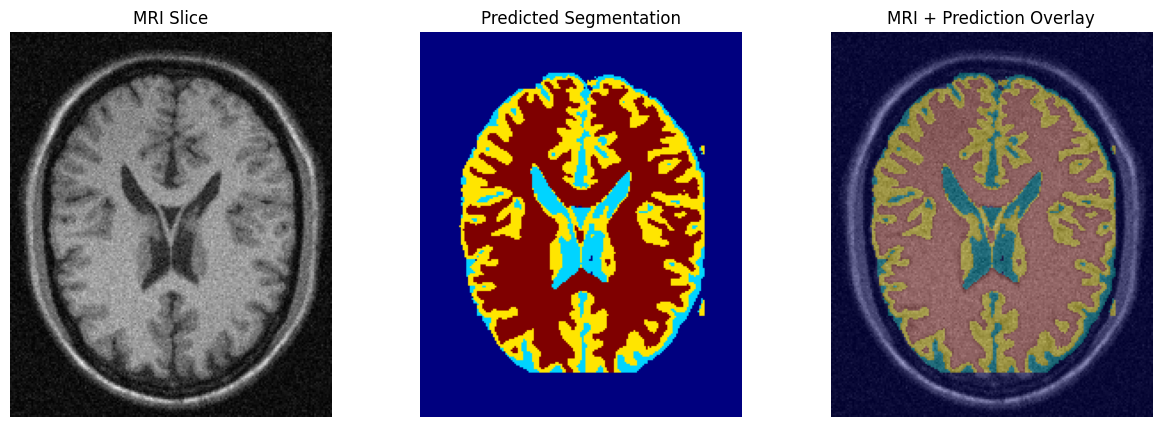


Saving Final Segmentation...

Segmentation Saved Successfully!

Inference Completed Successfully!

Attention U-Net Workflow

MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Softmax Probability Maps
     ↓
Patch Reconstruction
     ↓
Final Brain Segmentation


Attention 3D Brain Segmentation Completed!


In [11]:
# ============================================================
# ATTENTION 3D U-NET TRAINING + INFERENCE
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

# ============================================================
# PATCH CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# NUMBER OF CLASSES
# ============================================================

NUM_CLASSES = 4

print("\nClass Meaning")

print("""
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# CREATE DATASET
# ============================================================

print("\nCreating TensorDataset...")

dataset = TensorDataset(
    image_patches,
    mask_patches
)

print("\nDataset Created Successfully!")

print("\nTotal Samples =",
      len(dataset))

# ============================================================
# CREATE DATALOADER
# ============================================================

BATCH_SIZE = 2

print("\nCreating DataLoader...")

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\nDataLoader Created Successfully!")

# ============================================================
# VERIFY ONE BATCH
# ============================================================

print("\nChecking One Batch...")

sample_images, sample_masks = next(
    iter(loader)
)

print("\nImage Batch Shape =",
      sample_images.shape)

print("Mask Batch Shape =",
      sample_masks.shape)

print("\nTensor Meaning")

print("""
Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]
""")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# ATTENTION BLOCK
# ============================================================

class AttentionBlock(nn.Module):

    def __init__(
        self,
        F_g,
        F_l,
        F_int
    ):

        super(AttentionBlock, self).__init__()

        self.W_g = nn.Sequential(

            nn.Conv3d(
                F_g,
                F_int,
                kernel_size=1,
                stride=1,
                padding=0
            ),

            nn.BatchNorm3d(F_int)
        )

        self.W_x = nn.Sequential(

            nn.Conv3d(
                F_l,
                F_int,
                kernel_size=1,
                stride=1,
                padding=0
            ),

            nn.BatchNorm3d(F_int)
        )

        self.psi = nn.Sequential(

            nn.Conv3d(
                F_int,
                1,
                kernel_size=1,
                stride=1,
                padding=0
            ),

            nn.BatchNorm3d(1),

            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        out = x * psi

        return out

# ============================================================
# ATTENTION 3D U-NET
# ============================================================

class AttentionUNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super(AttentionUNet3D, self).__init__()

        print("\nBuilding Attention 3D U-Net...")

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ----------------------------------------------------
        # DECODER LEVEL 3
        # ----------------------------------------------------

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.att3 = AttentionBlock(
            F_g=128,
            F_l=128,
            F_int=64
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        # ----------------------------------------------------
        # DECODER LEVEL 2
        # ----------------------------------------------------

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.att2 = AttentionBlock(
            F_g=64,
            F_l=64,
            F_int=32
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        # ----------------------------------------------------
        # DECODER LEVEL 1
        # ----------------------------------------------------

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.att1 = AttentionBlock(
            F_g=32,
            F_l=32,
            F_int=16
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        b = self.bottleneck(p3)

        # ----------------------------------------------------
        # DECODER LEVEL 3
        # ----------------------------------------------------

        u3 = self.up3(b)

        e3 = self.att3(
            g=u3,
            x=e3
        )

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        # ----------------------------------------------------
        # DECODER LEVEL 2
        # ----------------------------------------------------

        u2 = self.up2(d3)

        e2 = self.att2(
            g=u2,
            x=e2
        )

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        # ----------------------------------------------------
        # DECODER LEVEL 1
        # ----------------------------------------------------

        u1 = self.up1(d2)

        e1 = self.att1(
            g=u1,
            x=e1
        )

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        out = self.final(d1)

        return out

# ============================================================
# CREATE MODEL
# ============================================================

print("\nCreating Attention 3D U-Net...")

model = AttentionUNet3D(
    in_channels=1,
    out_channels=NUM_CLASSES
).to(DEVICE)

print("\nAttention 3D U-Net Created Successfully!")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Created Successfully!")

# ============================================================
# TRAINING PARAMETERS
# ============================================================

EPOCHS = 30

# ============================================================
# TRAINING LOOP
# ============================================================

print("\nStarting Training...")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # --------------------------------------------------------
    # BATCH LOOP
    # --------------------------------------------------------

    for batch_index, (images, masks) in enumerate(loader):

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        outputs = model(images)

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            masks
        )

        # ----------------------------------------------------
        # CLEAR OLD GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()

        # ----------------------------------------------------
        # UPDATE WEIGHTS
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # TRACK LOSS
        # ----------------------------------------------------

        running_loss += loss.item()

        print(
            f"Batch {batch_index+1} "
            f"Loss = {loss.item():.4f}"
        )

    # --------------------------------------------------------
    # EPOCH LOSS
    # --------------------------------------------------------

    epoch_loss = (
        running_loss / len(loader)
    )

    print(
        f"\nEpoch {epoch+1} "
        f"Average Loss = "
        f"{epoch_loss:.4f}"
    )

# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\nTraining Completed Successfully!")

# ============================================================
# SAVE MODEL
# ============================================================

print("\nSaving Attention 3D U-Net Model...")

MODEL_PATH = "attention_unet3d_brain_segmentation.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("\nModel Saved Successfully!")

print("\nSaved Model File:")

print(MODEL_PATH)

# ============================================================
# STEP 14 — PROBABILITY MAPS
# ============================================================

print("\n================================================")
print("STEP 14 — PROBABILITY MAPS")
print("================================================")

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

print("\nLoading Trained Attention U-Net Model...")

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

model.eval()

print("\nModel Loaded Successfully!")

# ============================================================
# MRI VOLUME
# ============================================================

input_volume = volume

DEPTH, HEIGHT, WIDTH = input_volume.shape

print("\nMRI Volume Shape =",
      input_volume.shape)

# ============================================================
# CREATE EMPTY PREDICTION VOLUME
# ============================================================

print("\nCreating Empty Prediction Volume...")

prediction_volume = np.zeros(
    (
        NUM_CLASSES,
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# CREATE COUNT VOLUME
# ============================================================

count_volume = np.zeros(
    (
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# SLIDING WINDOW INFERENCE
# ============================================================

print("\nStarting Sliding Window Inference...")

patch_count = 0

with torch.no_grad():

    for z in range(
        0,
        DEPTH - PATCH_SIZE + 1,
        STRIDE
    ):

        for y in range(
            0,
            HEIGHT - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                WIDTH - PATCH_SIZE + 1,
                STRIDE
            ):

                # ------------------------------------------------
                # EXTRACT PATCH
                # ------------------------------------------------

                patch = input_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # ------------------------------------------------
                # SKIP EMPTY PATCHES
                # ------------------------------------------------

                if np.sum(patch) < 5:

                    continue

                # ------------------------------------------------
                # CONVERT TO TENSOR
                # ------------------------------------------------

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                )

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.to(DEVICE)

                # ------------------------------------------------
                # MODEL PREDICTION
                # ------------------------------------------------

                outputs = model(
                    patch_tensor
                )

                # ------------------------------------------------
                # SOFTMAX
                # ------------------------------------------------

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                probabilities = probabilities.cpu().numpy()[0]

                # ------------------------------------------------
                # STORE PREDICTIONS
                # ------------------------------------------------

                prediction_volume[
                    :,
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += probabilities

                # ------------------------------------------------
                # UPDATE COUNT
                # ------------------------------------------------

                count_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += 1

                patch_count += 1

                print(
                    f"Processed Patch {patch_count}"
                )

# ============================================================
# AVERAGE PREDICTIONS
# ============================================================

print("\nTotal Predicted Patches =",
      patch_count)

print("\nAveraging Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

print("\nPrediction Volume Shape =",
      prediction_volume.shape)

# ============================================================
# FINAL SEGMENTATION
# ============================================================

print("\nConverting Probabilities To Labels...")

final_segmentation9_40 = np.argmax(
    prediction_volume,
    axis=0
)

print("\nFinal Segmentation Shape =",
      final_segmentation9_40.shape)

# ============================================================
# UNIQUE LABELS
# ============================================================

print("\nUnique Predicted Labels")

print(np.unique(final_segmentation9_40))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# MRI
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    input_volume[slice_index],
    cmap='gray'
)

plt.title("MRI Slice")

plt.axis("off")

# ------------------------------------------------------------
# SEGMENTATION
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    final_segmentation9_40[slice_index],
    cmap='jet'
)

plt.title("Predicted Segmentation")

plt.axis("off")

# ------------------------------------------------------------
# OVERLAY
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    input_volume[slice_index],
    cmap='gray'
)

plt.imshow(
    final_segmentation9_40[slice_index],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Prediction Overlay")

plt.axis("off")

plt.show()

# ============================================================
# SAVE SEGMENTATION
# ============================================================

print("\nSaving Final Segmentation...")

np.save(
    "final_segmentation9_40.npy",
    final_segmentation9_40
)

print("\nSegmentation Saved Successfully!")

# ============================================================
# COMPLETE WORKFLOW
# ============================================================

print("\nInference Completed Successfully!")

print("\nAttention U-Net Workflow")

print("""
MRI Volume
     ↓
32×32×32 Patch Extraction
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Softmax Probability Maps
     ↓
Patch Reconstruction
     ↓
Final Brain Segmentation
""")

print("\nAttention 3D Brain Segmentation Completed!")



Visualization RAW Saved Successfully!
Saved File = final_segmentation_9_40.raw

Loaded Shape = (181, 217, 181)
Unique Intensities = [  0  45 111 150]


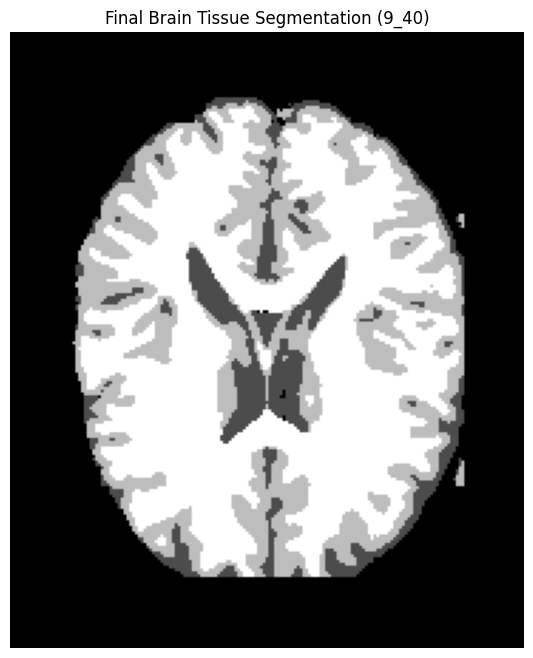


Intensity Mapping:

0   = Background
85  = CSF
170 = Gray Matter
255 = White Matter



In [25]:
# ============================================================
# SAVE SEGMENTATION FOR FIJI VISUALIZATION
# ============================================================

import numpy as np

# ============================================================
# CREATE VISUALIZATION VOLUME
# ============================================================

visual_volume = np.zeros(
    final_segmentation9_40.shape,
    dtype=np.uint8
)

# ============================================================
# ASSIGN BRIGHTER INTENSITIES
# ============================================================

# ------------------------------------------------------------
# BACKGROUND = 0
# ------------------------------------------------------------

visual_volume[
    final_segmentation9_40 == 0
] = 0

# ------------------------------------------------------------
# CSF = 85
# ------------------------------------------------------------

visual_volume[
    final_segmentation9_40 == 1
] = 45

# ------------------------------------------------------------
# GRAY MATTER = 170
# ------------------------------------------------------------

visual_volume[
    final_segmentation9_40 == 2
] = 111

# ------------------------------------------------------------
# WHITE MATTER = 255
# ------------------------------------------------------------

visual_volume[
    final_segmentation9_40 == 3
] = 150

# ============================================================
# SAVE RAW FILE
# ============================================================

output_path = "final_segmentation_9_40.raw"

visual_volume.tofile(
    output_path
)

print("\nVisualization RAW Saved Successfully!")

print("Saved File =", output_path)

# ============================================================
# VERIFY SAVED FILE
# ============================================================

loaded_volume = np.fromfile(
    output_path,
    dtype=np.uint8
)

loaded_volume = loaded_volume.reshape(
    181,
    217,
    181
)

print("\nLoaded Shape =",
      loaded_volume.shape)

print("Unique Intensities =",
      np.unique(loaded_volume))

# ============================================================
# VISUALIZE ONE SLICE
# ============================================================

import matplotlib.pyplot as plt

slice_index = 90

plt.figure(figsize=(8,8))

plt.imshow(
    loaded_volume[slice_index],
    cmap='gray'
)

plt.title(
    "Final Brain Tissue Segmentation (9_40)"
)

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("""
Intensity Mapping:

0   = Background
85  = CSF
170 = Gray Matter
255 = White Matter
""")


RAW Files Saved Successfully!

Saved Files:

1. csf_segmentation9_40.raw
2. gm_segmentation9_40.raw
3. wm_segmentation9_40.raw


CSF Unique Values = [  0 255]
GM Unique Values = [  0 180]
WM Unique Values = [  0 255]


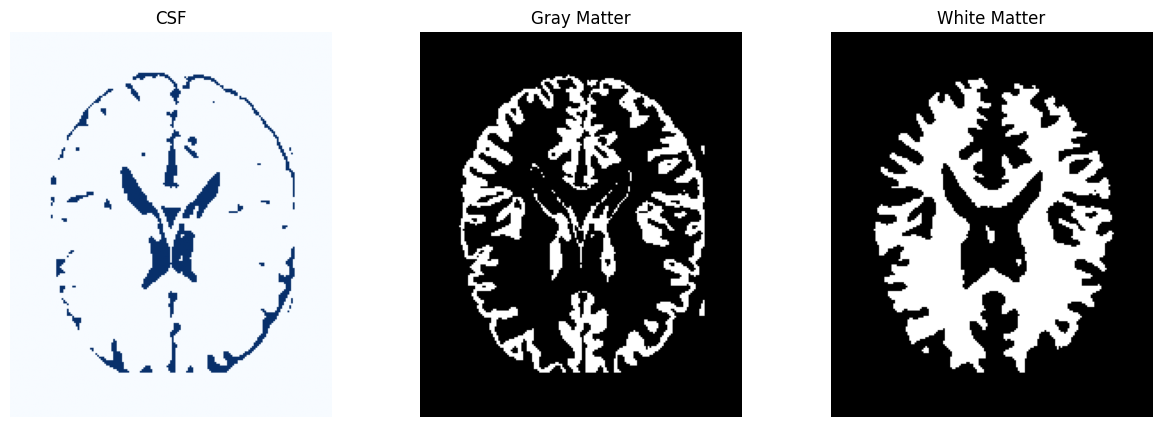


Segmentation Labels:

1 = CSF
2 = Gray Matter
3 = White Matter



In [ ]:
# ============================================================
# SAVE CSF, GRAY MATTER, WHITE MATTER
# AS SEPARATE RAW FILES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CREATE EMPTY VOLUMES
# ============================================================

csf_volume = np.zeros(
    final_segmentation9_40.shape,
    dtype=np.uint8
)

gm_volume = np.zeros(
    final_segmentation9_40.shape,
    dtype=np.uint8
)

wm_volume = np.zeros(
    final_segmentation9_40.shape,
    dtype=np.uint8
)

# ============================================================
# ASSIGN COLORS / INTENSITIES
# ============================================================

# ------------------------------------------------------------
# CSF → BRIGHT BLUE STYLE INTENSITY
# ------------------------------------------------------------

csf_volume[
    final_segmentation9_40 == 1
] = 255

# ------------------------------------------------------------
# GRAY MATTER → MEDIUM GRAY
# ------------------------------------------------------------

gm_volume[
    final_segmentation9_40 == 2
] = 180

# ------------------------------------------------------------
# WHITE MATTER → WHITE
# ------------------------------------------------------------

wm_volume[
    final_segmentation9_40 == 3
] = 255

# ============================================================
# SAVE RAW FILES
# ============================================================

csf_volume.tofile(
    "csf_segmentation9_40.raw"
)

gm_volume.tofile(
    "gm_segmentation9_40.raw"
)

wm_volume.tofile(
    "wm_segmentation9_40.raw"
)

print("\nRAW Files Saved Successfully!")

print("""
Saved Files:

1. csf_segmentation9_40.raw
2. gm_segmentation9_40.raw
3. wm_segmentation9_40.raw
""")

# ============================================================
# VERIFY FILES
# ============================================================

print("\nCSF Unique Values =",
      np.unique(csf_volume))

print("GM Unique Values =",
      np.unique(gm_volume))

print("WM Unique Values =",
      np.unique(wm_volume))

# ============================================================
# VISUALIZE SAMPLE SLICE
# ============================================================

slice_index = 90

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# CSF
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    csf_volume[slice_index],
    cmap='Blues'
)

plt.title("CSF")

plt.axis("off")

# ------------------------------------------------------------
# GRAY MATTER
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    gm_volume[slice_index],
    cmap='gray'
)

plt.title("Gray Matter")

plt.axis("off")

# ------------------------------------------------------------
# WHITE MATTER
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    wm_volume[slice_index],
    cmap='gray'
)

plt.title("White Matter")

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("""
Segmentation Labels:

1 = CSF
2 = Gray Matter
3 = White Matter
""")

In [26]:
# ============================================================
# CLASS-WISE ACCURACY + DICE SCORE EVALUATION
# ATTENTION 3D U-NET
# ============================================================

import numpy as np

print("Loading Ground Truth Segmentation...")

# ============================================================
# LOAD GROUND TRUTH
# ============================================================

ground_truth = np.fromfile(
    "phantom_1.0mm_normal_crisp.rawb",
    dtype=np.uint8
)

# ============================================================
# LOAD PREDICTED SEGMENTATION
# ============================================================

print("\nLoading Predicted Segmentation...")

predicted_segmentation = np.fromfile(
    "final_segmentation_9_40.raw",
    dtype=np.uint8
)

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH = 181
HEIGHT = 217
WIDTH = 181

# ============================================================
# RESHAPE
# ============================================================

ground_truth = ground_truth.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

predicted_segmentation = predicted_segmentation.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

# ============================================================
# FILTER GROUND TRUTH
# KEEP ONLY LABELS 0-3
# ============================================================

ground_truth[
    ground_truth > 3
] = 0


# ============================================================
# REMAP PREDICTION LABELS
# ============================================================

print("\nRemapping Predicted Labels...")

remapped_prediction = np.zeros_like(
    predicted_segmentation
)

remapped_prediction[
    predicted_segmentation == 45
] = 1

remapped_prediction[
    predicted_segmentation == 111
] = 2

remapped_prediction[
    predicted_segmentation == 150
] = 3

predicted_segmentation = remapped_prediction


# ============================================================
# CLASS ACCURACY FUNCTION
# ============================================================

def class_accuracy(
    prediction,
    target,
    class_label
):

    target_mask = (
        target == class_label
    )

    total_voxels = np.sum(
        target_mask
    )

    correct_voxels = np.sum(
        (prediction == class_label)
        &
        (target == class_label)
    )

    if total_voxels == 0:
        return 0.0

    accuracy = (
        correct_voxels /
        total_voxels
    )

    return accuracy


# ============================================================
# DICE SCORE FUNCTION
# ============================================================

def dice_score(
    prediction,
    target,
    class_label
):

    prediction_mask = (
        prediction == class_label
    )

    target_mask = (
        target == class_label
    )

    intersection = np.sum(
        prediction_mask
        &
        target_mask
    )

    total = (
        np.sum(prediction_mask)
        +
        np.sum(target_mask)
    )

    if total == 0:
        return 1.0

    dice = (
        2.0 * intersection
    ) / (
        total + 1e-8
    )

    return dice


# ============================================================
# CSF METRICS
# ============================================================

csf_accuracy = class_accuracy(
    predicted_segmentation,
    ground_truth,
    1
)

csf_dice = dice_score(
    predicted_segmentation,
    ground_truth,
    1
)

# ============================================================
# GM METRICS
# ============================================================

gm_accuracy = class_accuracy(
    predicted_segmentation,
    ground_truth,
    2
)

gm_dice = dice_score(
    predicted_segmentation,
    ground_truth,
    2
)

# ============================================================
# WM METRICS
# ============================================================

wm_accuracy = class_accuracy(
    predicted_segmentation,
    ground_truth,
    3
)

wm_dice = dice_score(
    predicted_segmentation,
    ground_truth,
    3
)

# ============================================================
# MEAN DICE
# ============================================================

mean_dice = (
    csf_dice +
    gm_dice +
    wm_dice
) / 3.0

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("FINAL RESULTS")
print("================================================")

print(f"""
CSF Accuracy (%) : {csf_accuracy*100:.2f}
GM Accuracy (%)  : {gm_accuracy*100:.2f}
WM Accuracy (%)  : {wm_accuracy*100:.2f}

------------------------------------------------

CSF Dice Score   : {csf_dice:.4f}
GM Dice Score    : {gm_dice:.4f}
WM Dice Score    : {wm_dice:.4f}

------------------------------------------------

Mean Dice Score  : {mean_dice:.4f}

""")

print("\nEvaluation Completed Successfully!")

Loading Ground Truth Segmentation...

Loading Predicted Segmentation...

Remapping Predicted Labels...

FINAL RESULTS

CSF Accuracy (%) : 72.93
GM Accuracy (%)  : 80.54
WM Accuracy (%)  : 97.66

------------------------------------------------

CSF Dice Score   : 0.7589
GM Dice Score    : 0.8502
WM Dice Score    : 0.8883

------------------------------------------------

Mean Dice Score  : 0.8325



Evaluation Completed Successfully!
